In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from solution import LogisticRegression

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(learning_rate=0.01, n_iterations=3000)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
print("Loss history (first 5):", model.loss_history[:5])
print("Loss history (last 5):", model.loss_history[-5:])

Train accuracy: 0.9824175824175824
Test accuracy: 0.9824561403508771
Loss history (first 5): [0.6931471805599453, 0.6739353141133738, 0.6559064972215113, 0.6389797634212732, 0.623076253001436]
Loss history (last 5): [0.07918391178395634, 0.07917756107878063, 0.07917121350663645, 0.07916486906486075, 0.07915852775079364]


### Sigmoid Function

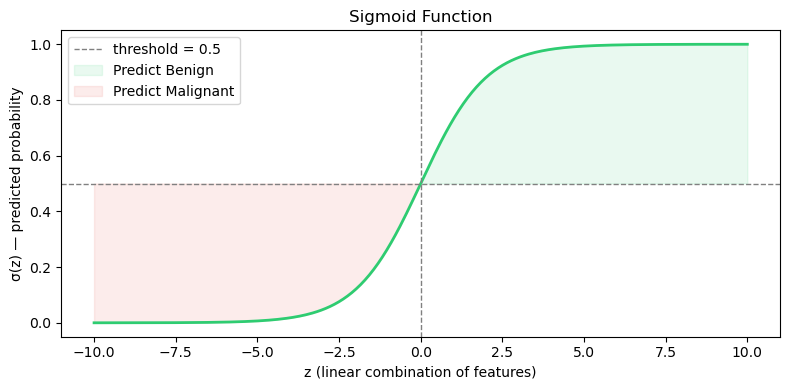

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from solution import LogisticRegression

# Setup — run this cell first, all others depend on it
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(learning_rate=0.01, n_iterations=3000)
model.fit(X_train, y_train)

# Sigmoid plot
z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, color='#2ecc71', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color='#2ecc71', label='Predict Benign')
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='#e74c3c', label='Predict Malignant')
plt.title('Sigmoid Function')
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) — predicted probability')
plt.legend()
plt.tight_layout()
plt.savefig('results/sigmoid_function.png', dpi=150, bbox_inches='tight')
plt.show()

### Loss Curve

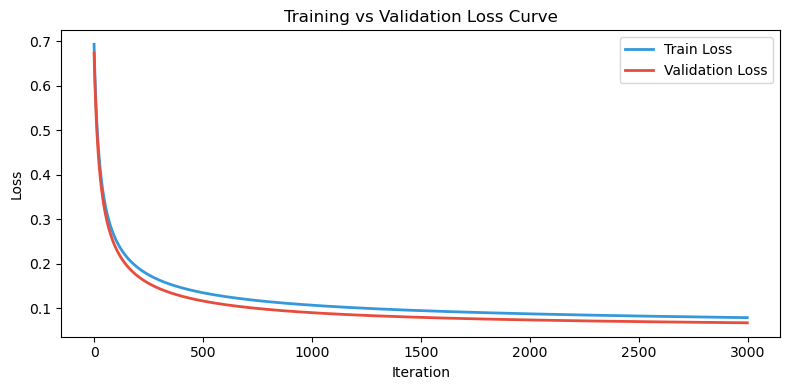

In [15]:
# Retrain with validation data
model.fit(X_train, y_train, X_val=X_test, y_val=y_test)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(model.val_loss_history, label='Validation Loss', color='#e74c3c', linewidth=2)
plt.title('Training vs Validation Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Decision Boundary (2 features)

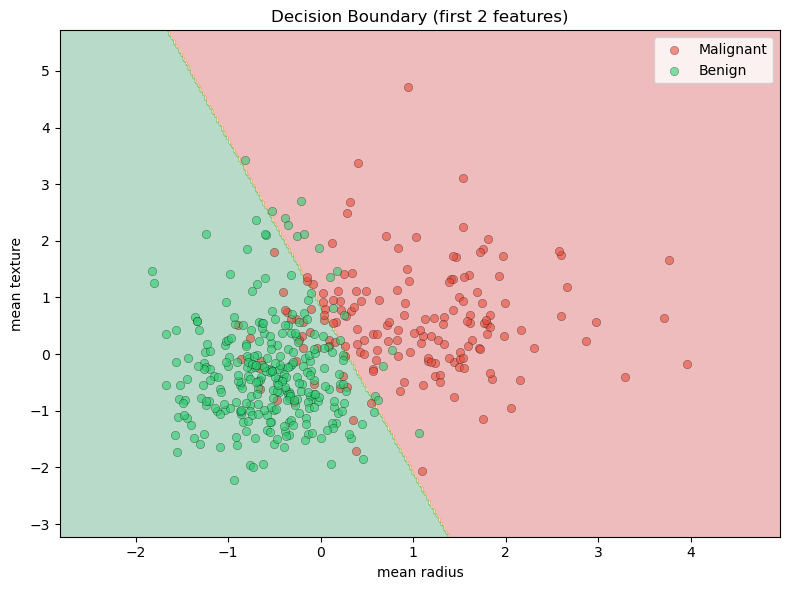

In [16]:
# Use only 2 features for visualization
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42)

scaler_2d = StandardScaler()
X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_test_2d = scaler_2d.transform(X_test_2d)

model_2d = LogisticRegression(learning_rate=0.01, n_iterations=3000)
model_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X_train_2d[y_train_2d==0, 0], X_train_2d[y_train_2d==0, 1],
            c='#e74c3c', label='Malignant', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.scatter(X_train_2d[y_train_2d==1, 0], X_train_2d[y_train_2d==1, 1],
            c='#2ecc71', label='Benign', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.title('Decision Boundary (first 2 features)')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend()
plt.tight_layout()
plt.savefig('results/decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrix

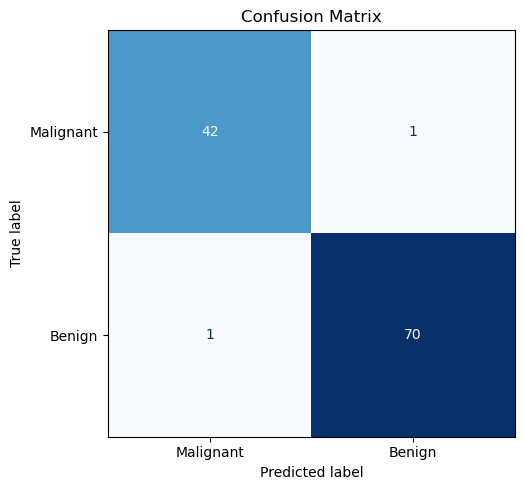

True Negatives  (Malignant correctly identified): 42
False Positives (Benign predicted as Malignant):  1
False Negatives (Malignant missed):               1
True Positives  (Benign correctly identified):    70


In [17]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Malignant', 'Benign'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Malignant correctly identified): {tn}")
print(f"False Positives (Benign predicted as Malignant):  {fp}")
print(f"False Negatives (Malignant missed):               {fn}")
print(f"True Positives  (Benign correctly identified):    {tp}")

### Precision-Recall Tradeoff

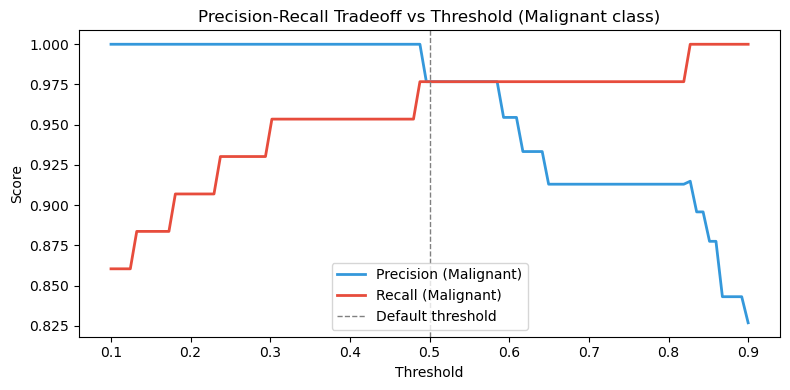

In [18]:
thresholds = np.linspace(0.1, 0.9, 100)
precisions = []
recalls = []

probs = model.predict_proba(X_test)

for t in thresholds:
    preds = (probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds, pos_label=0, zero_division=0))
    recalls.append(recall_score(y_test, preds, pos_label=0, zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions, label='Precision (Malignant)', color='#3498db', linewidth=2)
plt.plot(thresholds, recalls, label='Recall (Malignant)', color='#e74c3c', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold')
plt.title('Precision-Recall Tradeoff vs Threshold (Malignant class)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('results/precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

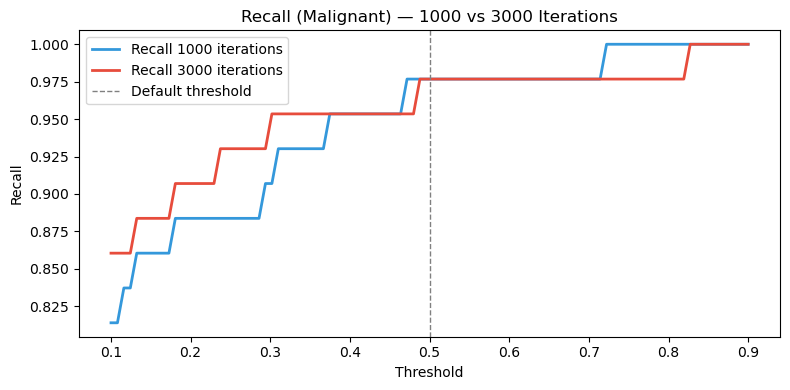

In [19]:
model_1000 = LogisticRegression(learning_rate=0.01, n_iterations=1000)
model_1000.fit(X_train, y_train)

model_3000 = LogisticRegression(learning_rate=0.01, n_iterations=3000)
model_3000.fit(X_train, y_train)

thresholds = np.linspace(0.1, 0.9, 100)
probs_1000 = model_1000.predict_proba(X_test)
probs_3000 = model_3000.predict_proba(X_test)

recalls_1000 = [recall_score(y_test, (probs_1000 >= t).astype(int), pos_label=0, zero_division=0) for t in thresholds]
recalls_3000 = [recall_score(y_test, (probs_3000 >= t).astype(int), pos_label=0, zero_division=0) for t in thresholds]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, recalls_1000, label='Recall 1000 iterations', color='#3498db', linewidth=2)
plt.plot(thresholds, recalls_3000, label='Recall 3000 iterations', color='#e74c3c', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold')
plt.title('Recall (Malignant) — 1000 vs 3000 Iterations')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import importlib
import solution
importlib.reload(solution)
from solution import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Setup
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = LogisticRegression(learning_rate=0.01, n_iterations=3000)
model.fit(X_train, y_train)

# Threshold comparison
probs = model.predict_proba(X_test)

for threshold in [0.5, 0.85]:
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    print(f"\n{'='*45}")
    print(f"Threshold = {threshold}")
    print(f"{'='*45}")
    print(f"Accuracy:            {accuracy_score(y_test, preds):.4f}")
    print(f"Malignant Recall:    {recall_score(y_test, preds, pos_label=0):.4f}")
    print(f"Malignant Precision: {precision_score(y_test, preds, pos_label=0):.4f}")
    print(f"F1 (Malignant):      {f1_score(y_test, preds, pos_label=0):.4f}")
    print(f"TN (malignant correctly caught):    {tn}")
    print(f"FP (malignant missed — sent home):  {fp}")   
    print(f"FN (benign falsely flagged):        {fn}")   
    print(f"TP (benign correctly cleared):      {tp}")


Threshold = 0.5
Accuracy:            0.9825
Malignant Recall:    0.9767
Malignant Precision: 0.9767
F1 (Malignant):      0.9767
TN (malignant correctly caught):    42
FP (malignant missed — sent home):  1
FN (benign falsely flagged):        1
TP (benign correctly cleared):      70

Threshold = 0.85
Accuracy:            0.9474
Malignant Recall:    1.0000
Malignant Precision: 0.8776
F1 (Malignant):      0.9348
TN (malignant correctly caught):    43
FP (malignant missed — sent home):  0
FN (benign falsely flagged):        6
TP (benign correctly cleared):      65
